# Extended Data Figure 9. Follow-up biopsy sample overview and cytokine rejection type comparisons a, Overview of pre-treatment Xenium biopsy clinical parameters

3 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/ED9"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## ED9 a

ED 9a — follow-up (post-treatment) biopsy overview: clinical tracks, immune fraction, foci, largest focus, Level-4 immune composition (heart_l4_recovery/panel_d_prolif_resolved.py post).

Input:
- `heart_results/manuscript_restyle/Fig6/atlas_tables/amr_axis_features_ATLAS.csv`
- `heart_results/rejection_prediction/tables/{predict_next_transitions,xenium_atlas_labels,xenium_lymphoid8_annotation}.csv`

Source: `figures/ED9/panel_a.py`

biopsies: 103 | per patient-type: {'cellular_rejection': 74, 'mixed_rejection': 20, 'antibody_rejection': 9}


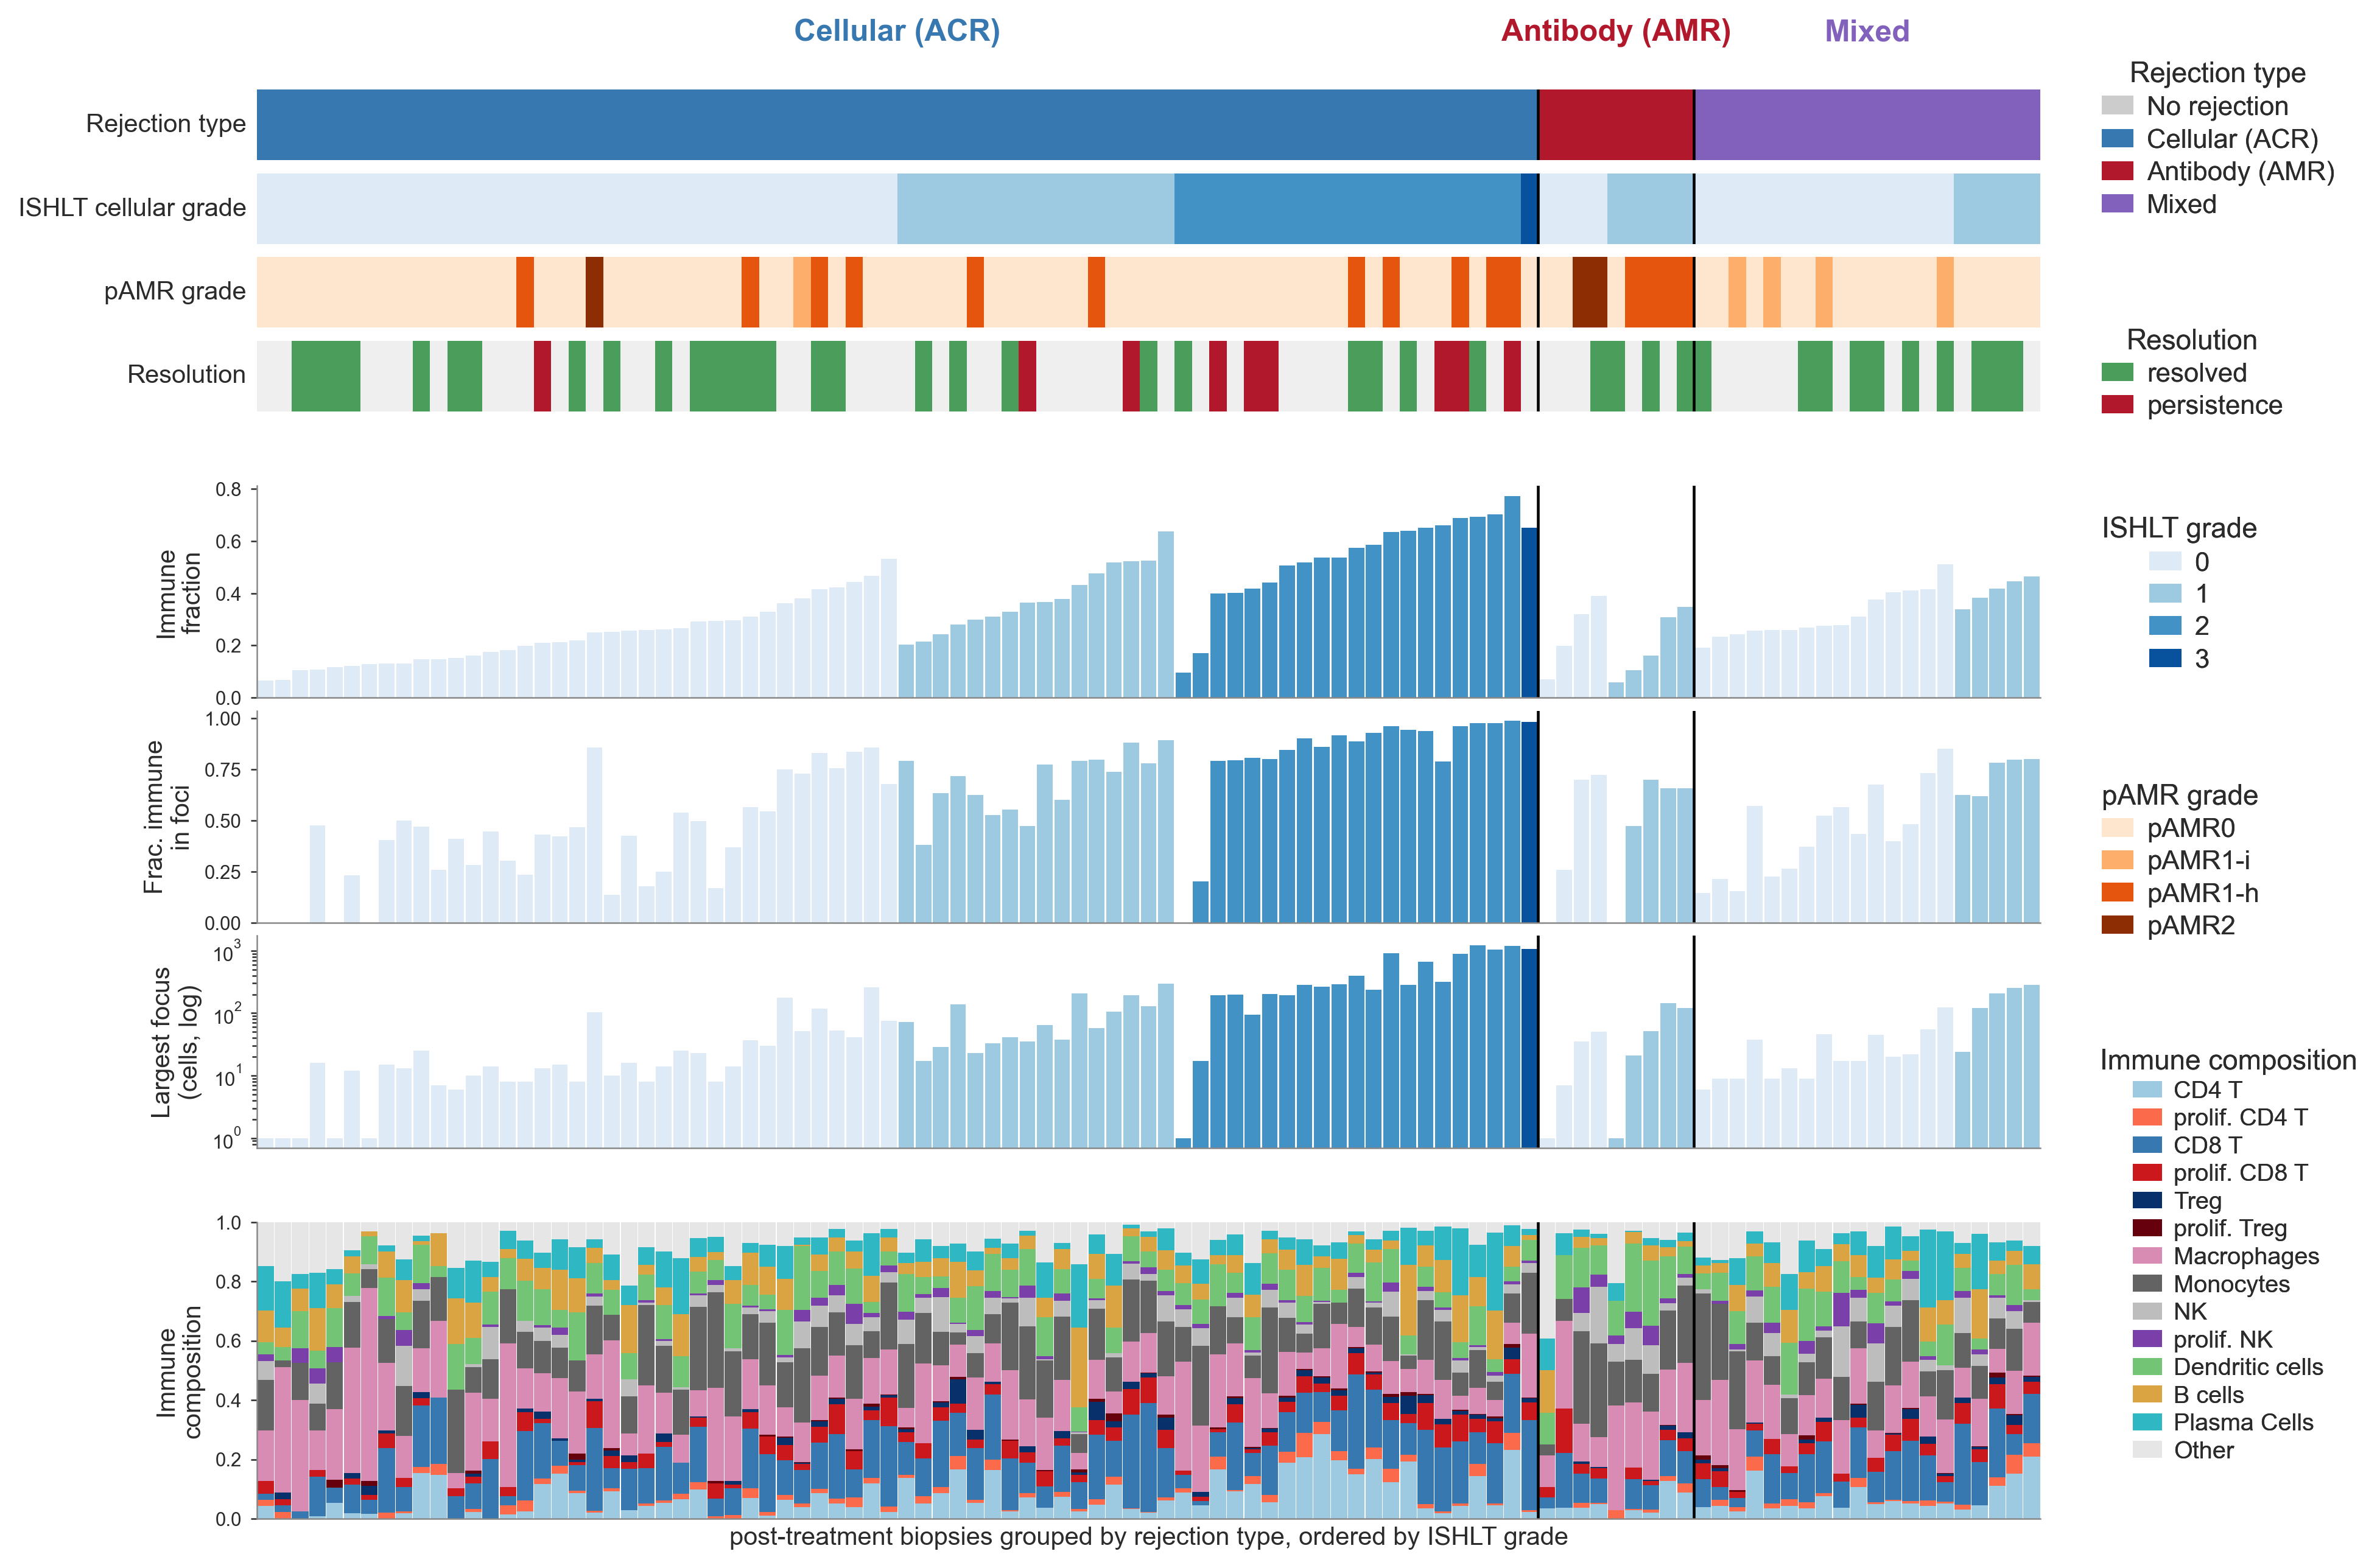

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
SRC = f"{TABLES}/heart_results/manuscript_restyle/Fig6"
TAB = f"{TABLES}/heart_results/rejection_prediction/tables/"
TIMING = "post"
FIG, PANEL = "ED9", "a"

d = pd.read_csv(SRC + "/atlas_tables/amr_axis_features_ATLAS.csv")
d = d.dropna(subset=["biopsy_cellular_grading", "dbscan_frac_in_agg"]).copy()
d["g"] = d.biopsy_cellular_grading.astype(int)
d["rej"] = d.biopsy_rejection_type.astype(str).str.strip()
d["pamr"] = d.biopsy_antibody_grading.astype(str).str.strip()
d["largest_cells"] = (d.dbscan_largest_agg_frac * d.n_immune).clip(lower=1)
pt = pd.read_csv(TAB + "predict_next_transitions.csv")
res = {r.cur_Sample: ("resolved" if r.next_grade < 2 else "persistence") for r in pt.itertuples()}
d["res"] = d.Sample.map(res).fillna("na")

lab = pd.read_csv(TAB + "xenium_atlas_labels.csv", usecols=["cell_id", "Sample", "atlas_L3"])
l8 = pd.read_csv(TAB + "xenium_lymphoid8_annotation.csv", usecols=["cell_id", "label8"])
lab = lab.merge(l8, on="cell_id", how="left")
L8MAP = {"CD4 T cells": "CD4 T", "CD8 T cells": "CD8 T", "Tregs": "Treg", "NK cells": "NK",
         "Proliferating CD4 T cells": "prolif. CD4 T", "Proliferating CD8 T cells": "prolif. CD8 T",
         "Proliferating Tregs": "prolif. Treg", "Proliferating NK cells": "prolif. NK"}
L3MAP = {"Macrophages": "Macrophages", "Monocytes": "Monocytes", "Dendritic cells": "Dendritic cells",
         "B cells": "B cells", "Plasma Cells": "Plasma Cells", "Mast cells": "Other", "ILC": "Other"}
lab["cat"] = np.where(lab.label8.notna(), lab.label8.map(L8MAP), lab.atlas_L3.map(L3MAP))
imm = lab[lab.cat.notna()]
COMP = ["CD4 T", "prolif. CD4 T", "CD8 T", "prolif. CD8 T", "Treg", "prolif. Treg",
        "Macrophages", "Monocytes", "NK", "prolif. NK", "Dendritic cells", "B cells",
        "Plasma Cells", "Other"]
comp = pd.crosstab(imm.Sample, imm.cat, normalize="index").reindex(columns=COMP).fillna(0.0)
nimm = imm.groupby("Sample").size()

meta = pd.read_csv(TAB + "xenium_atlas_labels.csv",
                   usecols=["Sample", "patient_rejection_type", "biopsy_timing"]).drop_duplicates("Sample").set_index("Sample")
d["prt"] = d.Sample.map(meta["patient_rejection_type"]).astype(str).str.strip()
REJO = ["cellular_rejection", "antibody_rejection", "mixed_rejection"]
d = d[d.prt.isin(REJO)].copy()
d = d[d.Sample.map(meta["biopsy_timing"]).astype(str).str.strip() == TIMING].copy()
d = d[d.Sample.isin(comp.index[nimm.reindex(comp.index).fillna(0) >= 25])]
d["ro"] = d.prt.map({k: i for i, k in enumerate(REJO)})
d = d.sort_values(["ro", "g", "immune_fraction"]).reset_index(drop=True)
comp = comp.loc[d.Sample.values]
n = len(d)
print("biopsies:", n, "| per patient-type:", d.prt.value_counts().to_dict())
bnd = np.where(np.diff(d.ro.values) != 0)[0] + 0.0

GR = ["#deebf7", "#9ecae1", "#4292c6", "#08519c"]
REJ_C = {"no_rejection": "#cccccc", "cellular_rejection": "#3878b0",
         "antibody_rejection": "#B2182B", "mixed_rejection": "#8161bc"}
PAMR = ["pAMR0", "pAMR1-i", "pAMR1-h", "pAMR2"]
PAMR_C = dict(zip(PAMR, ["#fee6ce", "#fdae6b", "#e6550d", "#8c2d04"]))
RES_C = {"resolved": "#4a9d5b", "persistence": "#B2182B", "na": "#efefef"}
COMP_C = {"CD4 T": "#9ecae1", "prolif. CD4 T": "#fb6a4a", "CD8 T": "#3878b0",
          "prolif. CD8 T": "#cb181d", "Treg": "#08306b", "prolif. Treg": "#67000d",
          "Macrophages": "#d98cb3", "Monocytes": "#636363", "NK": "#bdbdbd",
          "prolif. NK": "#7a3fa8", "Dendritic cells": "#74c476", "B cells": "#d9a441",
          "Plasma Cells": "#2fb8c4", "Other": "#e6e6e6"}

fig = plt.figure(figsize=(15.5, 8.6))
gs = gridspec.GridSpec(10, 1, height_ratios=[0.5, 0.5, 0.5, 0.5, 0.34, 1.5, 1.5, 1.5, 0.34, 2.1],
                       hspace=0.10, left=0.12, right=0.75, top=0.96, bottom=0.05)


def strip(ax, vals, cmap, label):
    for i, v in enumerate(vals):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1,
                     fc=(cmap.get(v, "#efefef") if isinstance(cmap, dict) else cmap[int(v)]), ec="none"))
    ax.set_xlim(0, n); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
    for b in bnd:
        ax.axvline(b + 1, color="k", lw=1.1)


axs = [fig.add_subplot(gs[i]) for i in range(4)]
strip(axs[0], d.prt.values, REJ_C, "Rejection type")
strip(axs[1], d.g.values, GR, "ISHLT cellular grade")
strip(axs[2], d.pamr.values, PAMR_C, "pAMR grade")
strip(axs[3], d.res.values, RES_C, "Resolution")
for grp, lab_ in [("cellular_rejection", "Cellular (ACR)"), ("antibody_rejection", "Antibody (AMR)"),
                  ("mixed_rejection", "Mixed")]:
    idx = np.where(d.prt.values == grp)[0]
    if len(idx):
        axs[0].text((idx.min() + idx.max()) / 2 + 0.5, 1.6, lab_, ha="center", va="bottom",
                    fontsize=12, fontweight="bold", color=REJ_C[grp])


def bars(ax, vals, label, logy=False):
    ax.bar(np.arange(n) + 0.5, vals, width=0.9, color=[GR[gg] for gg in d.g.values], edgecolor="none")
    ax.set_xlim(0, n); ax.set_xticks([])
    if logy:
        ax.set_yscale("log")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_ylabel(label, fontsize=10)
    for b in bnd:
        ax.axvline(b + 1, color="k", lw=1.1)


bars(fig.add_subplot(gs[5]), d.immune_fraction.values, "Immune\nfraction")
bars(fig.add_subplot(gs[6]), d.dbscan_frac_in_agg.values, "Frac. immune\nin foci")
bars(fig.add_subplot(gs[7]), d.largest_cells.values, "Largest focus\n(cells, log)", logy=True)

axc = fig.add_subplot(gs[9]); bottom = np.zeros(n)
for ct in COMP:
    v = comp[ct].values
    axc.bar(np.arange(n) + 0.5, v, bottom=bottom, width=0.96, color=COMP_C[ct], edgecolor="none")
    bottom += v
axc.set_xlim(0, n); axc.set_ylim(0, 1); axc.set_xticks([])
axc.set_ylabel("Immune\ncomposition", fontsize=10)
for sp in ("top", "right"):
    axc.spines[sp].set_visible(False)
for b in bnd:
    axc.axvline(b + 1, color="k", lw=1.1)
axc.set_xlabel(f"{TIMING}-treatment biopsies grouped by rejection type, ordered by ISHLT grade",
               fontsize=10, labelpad=3)

L = [("Rejection type", [Patch(fc=REJ_C[k], label=v) for k, v in
      [("no_rejection", "No rejection"), ("cellular_rejection", "Cellular (ACR)"),
       ("antibody_rejection", "Antibody (AMR)"), ("mixed_rejection", "Mixed")]], 0.99),
     ("Resolution", [Patch(fc=RES_C["resolved"], label="resolved"),
                     Patch(fc=RES_C["persistence"], label="persistence")], 0.82),
     ("ISHLT grade", [Patch(fc=GR[i], label=str(i)) for i in range(4)], 0.70),
     ("pAMR grade", [Patch(fc=PAMR_C[k], label=k) for k in PAMR], 0.53),
     ("Immune composition", [Patch(fc=COMP_C[c], label=c) for c in COMP], 0.36)]
for title, handles, y in L:
    fs = 9.5 if title == "Immune composition" else 10.5
    lg = fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.765, y), fontsize=fs,
                    title=title, title_fontsize=11, handlelength=1.2, handletextpad=0.5,
                    labelspacing=0.24 if title == "Immune composition" else 0.3, frameon=False)
    fig.add_artist(lg)
save(fig, FIG, PANEL, bbox_inches="tight")


## ED9 b, c

ED 9b/9c — cytokine-response programme scores by rejection type for the 16 programmes not in Fig 6i: Kruskal-Wallis (q = BH over 18 programmes), pairwise MWU brackets (cells of fig6_v9_cytokine_panels.py, re-laid out as printed).

Input:
- `storage/GSE290577_heart_spatial_metadata.txt`
- `heart_results/manuscript_restyle/Fig6/atlas_tables/per_biopsy_scores_immune_ATLAS.csv`

Source: `figures/ED9/panel_bc.py`

n=95 biopsies / 60 patients | {'no_rejection': 37, 'cellular_rejection': 39, 'antibody_rejection': 14, 'mixed_rejection': 5}
   IL-21: Kruskal p=0.00971 q=0.025 | none vs cellular q=0.0234; none vs mixed q=0.0234
   IL-18: Kruskal p=0.0119 q=0.0268 | none vs mixed q=0.019; cellular vs mixed q=0.00109; antibody vs mixed q=0.00109
   IL-6: Kruskal p=0.0497 q=0.0745 | no pairwise hit
   IL-1α: Kruskal p=0.0953 q=0.132 | no pairwise hit
   OSM: Kruskal p=0.351 q=0.372 | no pairwise hit
   IL-10: Kruskal p=0.586 q=0.586 | no pairwise hit
   IFN-α1: Kruskal p=0.000889 q=0.00533 | none vs cellular q=0.00288; cellular vs antibody q=0.0138
   IL-4: Kruskal p=0.233 q=0.27 | no pairwise hit


   IL-15: Kruskal p=0.00174 q=0.00785 | none vs cellular q=0.0055; cellular vs mixed q=0.0144
   IL-2: Kruskal p=0.00284 q=0.0102 | none vs cellular q=0.00765; cellular vs mixed q=0.0194
   TNF-α: Kruskal p=0.00791 q=0.0237 | none vs cellular q=0.0196; cellular vs antibody q=0.0321
   GM-CSF: Kruskal p=0.138 q=0.177 | no pairwise hit
   IL-12: Kruskal p=0.0204 q=0.0409 | none vs cellular q=0.0171
   M-CSF: Kruskal p=0.0292 q=0.0526 | none vs mixed q=0.00718; cellular vs mixed q=0.0206; antibody vs mixed q=0.0206
   IFN-γ: Kruskal p=0.0335 q=0.0549 | none vs cellular q=0.0353
   IL-13: Kruskal p=0.24 q=0.27 | no pairwise hit


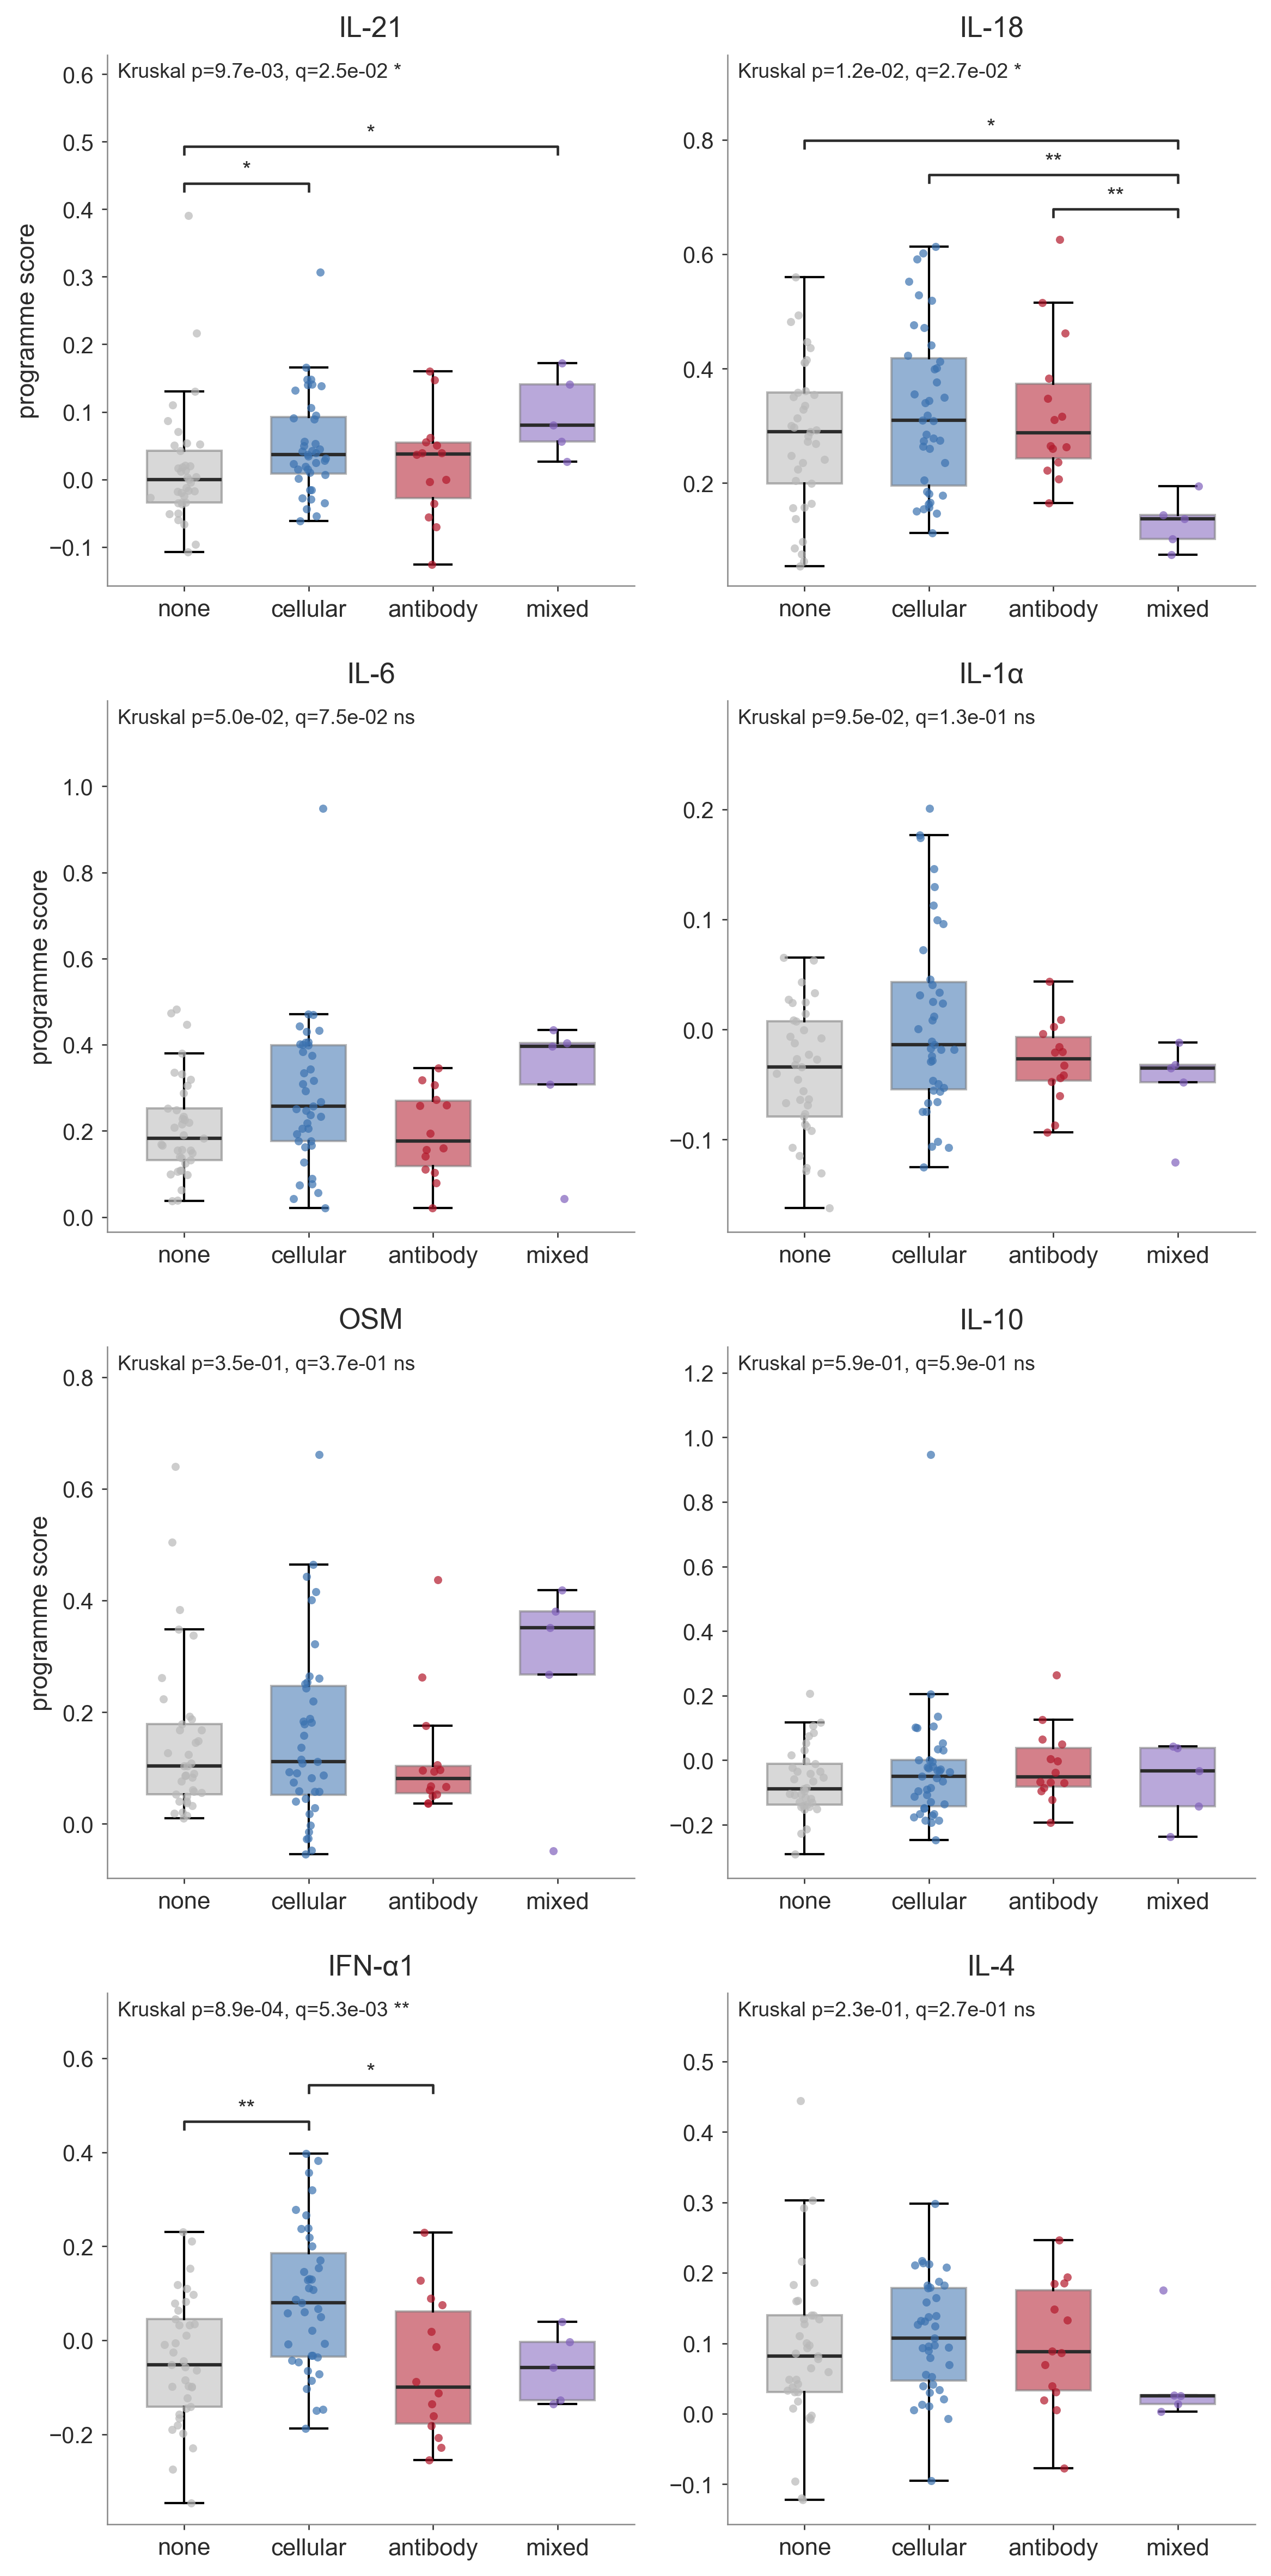

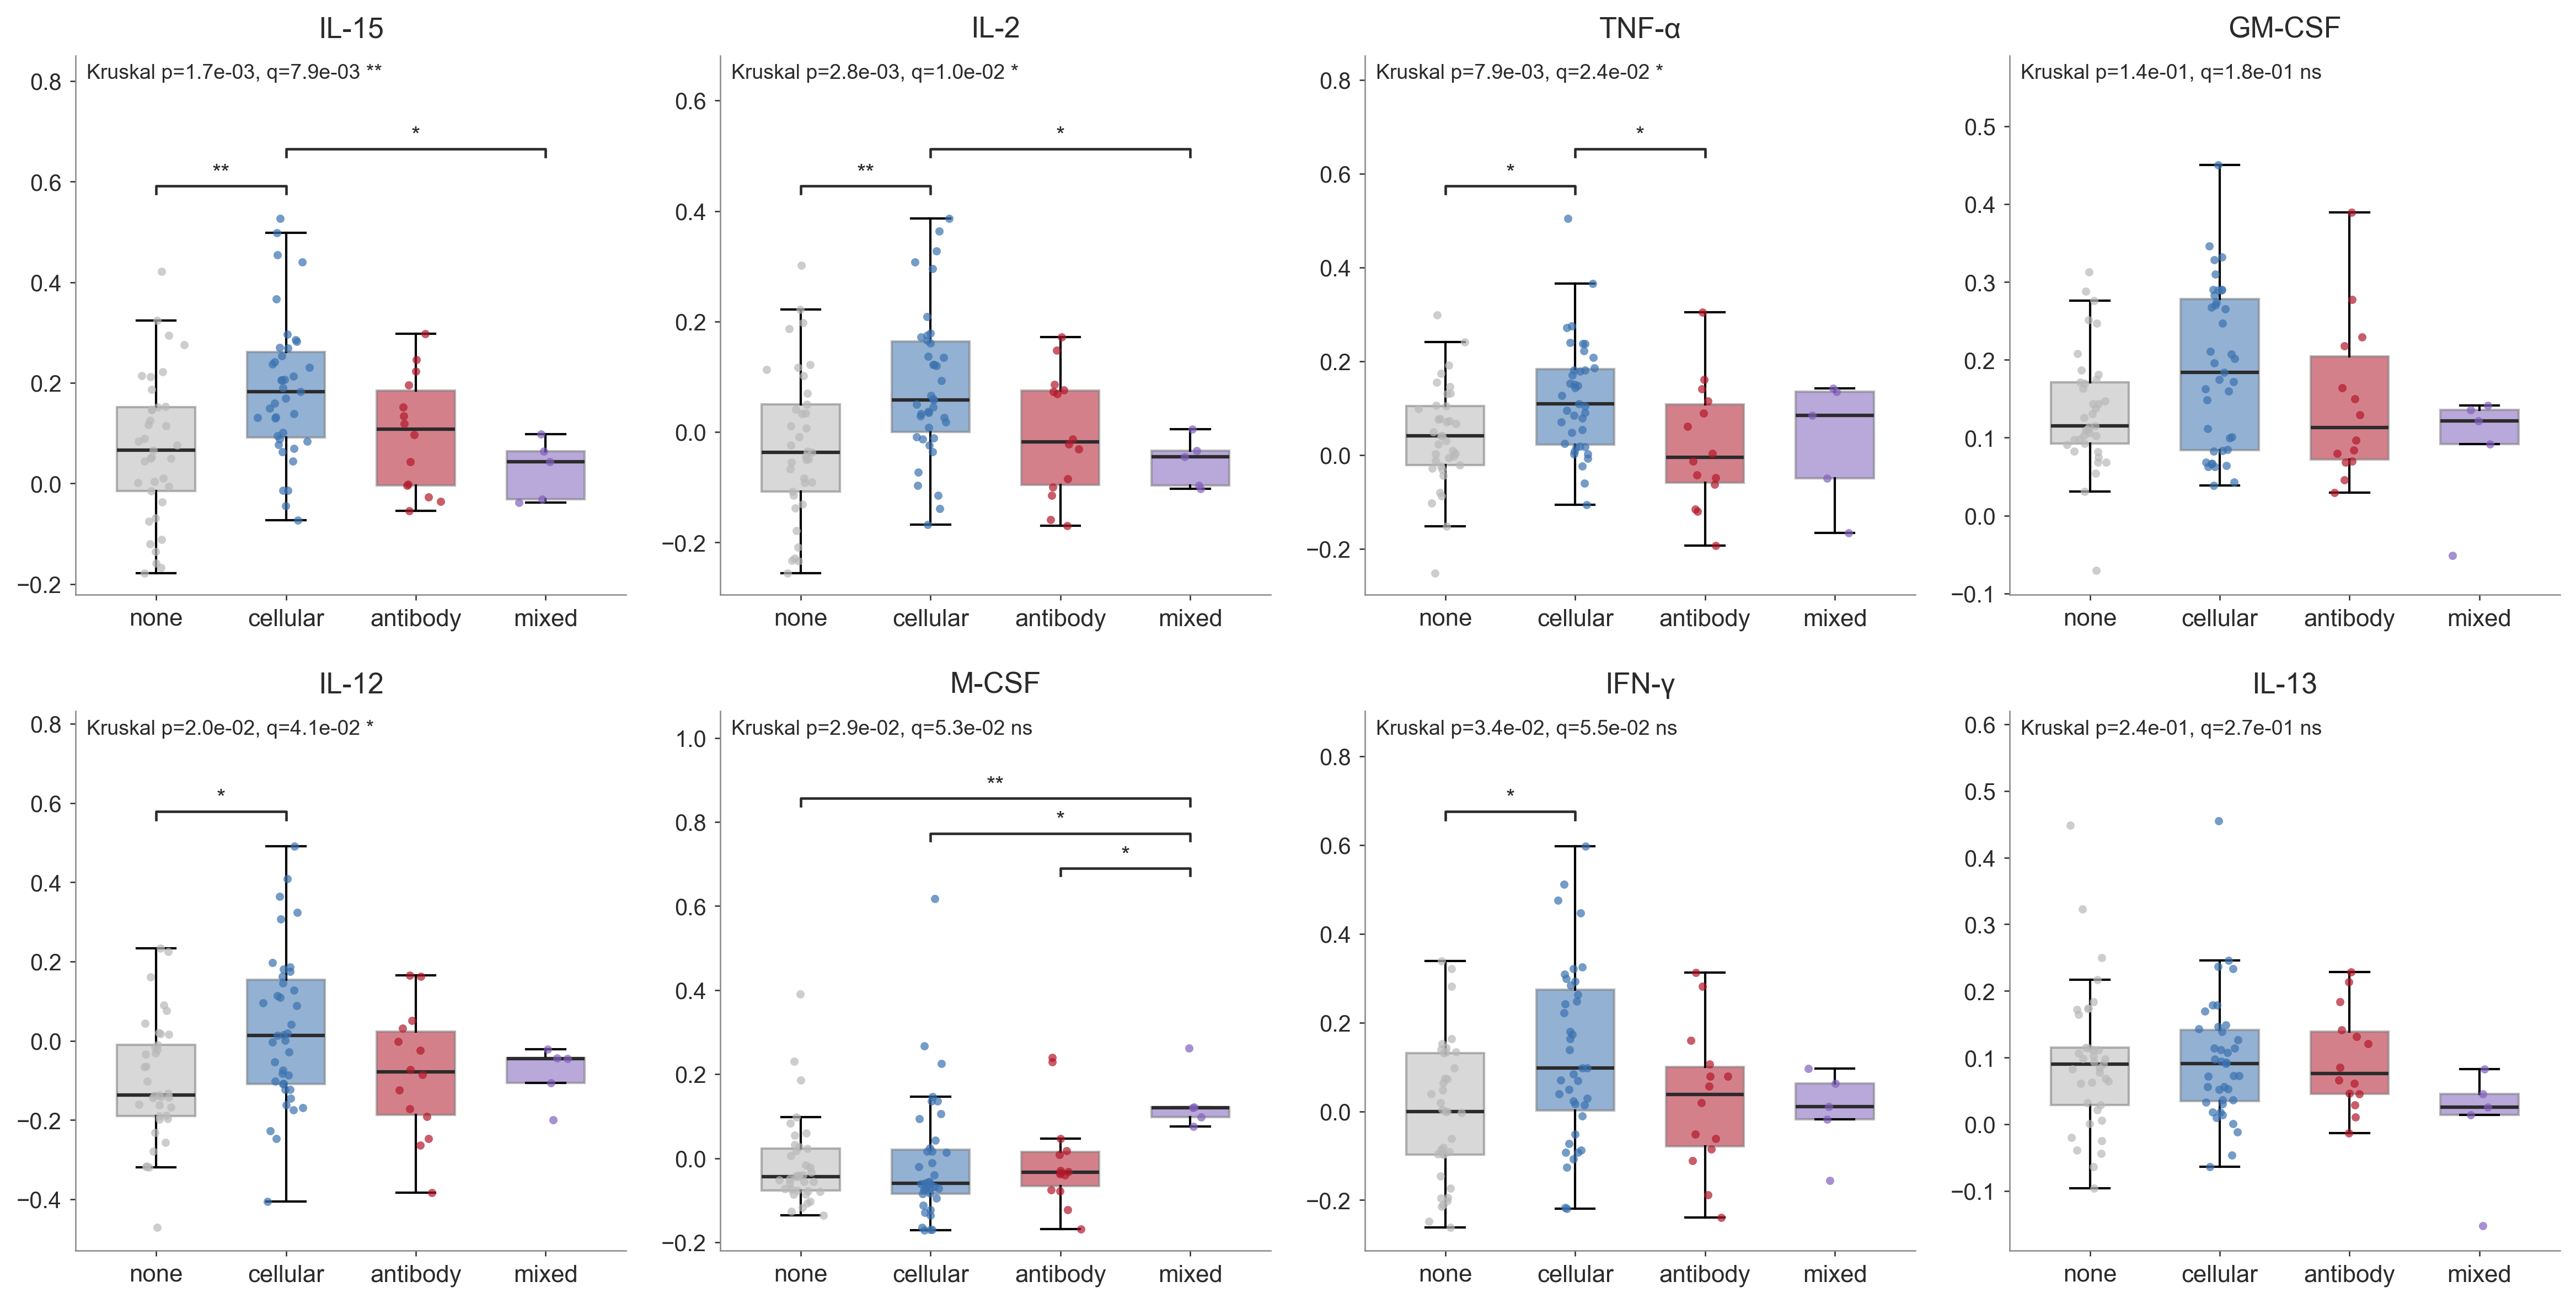

In [3]:
import itertools
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
import matplotlib.pyplot as plt
from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
mpl.rcParams.update({"axes.titlesize": 12.5, "axes.labelsize": 11,
                     "xtick.labelsize": 10.5, "ytick.labelsize": 10})
META = f"{TABLES}/storage/GSE290577_heart_spatial_metadata.txt"
ATL = f"{TABLES}/heart_results/manuscript_restyle/Fig6/atlas_tables/"
REJ4 = ["no_rejection", "cellular_rejection", "antibody_rejection", "mixed_rejection"]
REJ3 = REJ4[1:]
XLAB = ["none", "cellular", "antibody", "mixed"]
RCOL = {"no_rejection": "#B9B9B9", "cellular_rejection": "#3B72B0",
        "antibody_rejection": "#B2182B", "mixed_rejection": "#8161BC"}
GREEK = {"IL-1-beta": "IL-1β", "IL-1-alpha": "IL-1α", "IFN-beta": "IFN-β",
         "IFN-alpha1": "IFN-α1", "IFN-gamma": "IFN-γ", "TNF-alpha": "TNF-α"}
NCOL, ALPHA, DROP = 5, 0.05, ["IL-1β"]
B_GRID = [["IL-21", "IL-18"], ["IL-6", "IL-1α"], ["OSM", "IL-10"], ["IFN-α1", "IL-4"]]
C_GRID = [["IL-15", "IL-2", "TNF-α", "GM-CSF"], ["IL-12", "M-CSF", "IFN-γ", "IL-13"]]


def nice(k):
    k = k.replace("score_", "")
    return GREEK.get(k, k)


def worst(s):
    v = [x for x in s if x in REJ3]
    return v[0] if v else ("no_rejection" if "no_rejection" in list(s) else np.nan)


md = pd.read_csv(META, sep="\t")
md["rej"] = md.biopsy_rejection_type.astype(str).str.strip().replace("nan", np.nan)
md["bxid"] = md.patient_id.astype(str) + "@d" + md.days_from_transplant_to_biopsy.astype(str)
sc = pd.read_csv(ATL + "per_biopsy_scores_immune_ATLAS.csv").set_index("Sample")
cyto = [c for c in sc.columns if c.startswith("score_")]
c = md.set_index("Sample")
for k in cyto:
    c[k] = sc[k]
M = pd.DataFrame({"patient": c.groupby("bxid").patient_id.first(),
                  "timing": c.groupby("bxid").biopsy_timing.first(),
                  "rej": c.groupby("bxid").rej.apply(worst),
                  "ncore": c.groupby("bxid").size()})
for f in cyto:
    M[f] = c.groupby("bxid")[f].mean()
M["core_neg"] = (M.rej == "no_rejection") & (M.timing == "pre")
S = M[~M.core_neg]
Hb = S.dropna(subset=["rej"] + cyto)
sizes = {g: int((Hb.rej == g).sum()) for g in REJ4}
assert [sizes[g] for g in REJ4] == [37, 39, 14, 5] and len(Hb) == 95, "cohort does not reproduce"
print(f"n={len(Hb)} biopsies / {Hb.patient.nunique()} patients | {sizes}")

prs = list(itertools.combinations(range(4), 2))
vals = {k: [Hb.loc[Hb.rej == g, k].values for g in REJ4] for k in cyto}
kp = np.array([stats.kruskal(*vals[k]).pvalue for k in cyto])
kq = multipletests(kp, method="fdr_bh")[1]
KP, KQ = dict(zip(cyto, kp)), dict(zip(cyto, kq))
PQ = {k: multipletests([stats.mannwhitneyu(vals[k][i], vals[k][j]).pvalue for i, j in prs],
                       method="fdr_bh")[1] for k in cyto}
sel = sorted([k for k in cyto if nice(k) not in DROP], key=lambda k: (KP[k], KQ[k]))
rng = np.random.default_rng(0)                    # composite order -> identical jitter sequence
JIT = {k: [rng.normal(i, .07, len(z)) for i, z in enumerate(vals[k])] for k in sel}
POS = {k: n for n, k in enumerate(sel)}


def draw(ax, k):
    v = vals[k]
    bp = ax.boxplot(v, positions=range(4), widths=.6, patch_artist=True, showfliers=False,
                    medianprops=dict(color=H.INK, lw=1.5))
    for pt_, g in zip(bp["boxes"], REJ4):
        pt_.set_facecolor(RCOL[g]); pt_.set_alpha(.55); pt_.set_edgecolor(H.MUTED)
    for i, z in enumerate(v):
        ax.scatter(JIT[k][i], z, s=13, color=RCOL[REJ4[i]], alpha=.7, lw=0, zorder=3)
    ymx = max(np.max(z) for z in v); ymn = min(np.min(z) for z in v); ry = ymx - ymn
    sig = sorted([(i, j, q) for (i, j), q in zip(prs, PQ[k]) if q < ALPHA],
                 key=lambda t: (t[1] - t[0], t[0]))
    lvl = 0
    for i, j, q_ in sig:
        y = ymx + .07 * ry + lvl * .105 * ry
        ax.plot([i, i, j, j], [y, y + .022 * ry, y + .022 * ry, y], color=H.INK, lw=1.1)
        ax.text((i + j) / 2, y + .028 * ry, H.stars(q_), ha="center", va="bottom", fontsize=10)
        lvl += 1
    top_br = ymx + .07 * ry + (max(lvl - 1, 0)) * .105 * ry + (.085 * ry if lvl else 0)
    ax.set_ylim(ymn - .06 * ry, max(top_br, ymx + .07 * ry) + .20 * ry)
    ax.text(.02, .985, f"Kruskal p={KP[k]:.1e}, q={KQ[k]:.1e} {H.stars(KQ[k])}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9)
    ax.set_xlim(-.62, 3.62)
    ax.set_xticks(range(4)); ax.set_xticklabels(XLAB)
    ax.set_title(nice(k), fontsize=12.5, pad=8)
    if POS[k] % NCOL == 0:
        ax.set_ylabel("programme score")
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    print(f"   {nice(k)}: Kruskal p={KP[k]:.3g} q={KQ[k]:.3g} | "
          + ("; ".join(f"{XLAB[i]} vs {XLAB[j]} q={q:.3g}" for (i, j), q in zip(prs, PQ[k]) if q < ALPHA) or "no pairwise hit"))


byname = {nice(k): k for k in cyto}
for grid, tag in [(B_GRID, "b"), (C_GRID, "c")]:
    nr, nc = len(grid), len(grid[0])
    fig, axes = plt.subplots(nr, nc, figsize=(3.9 * nc, 3.95 * nr))
    for r in range(nr):
        for q in range(nc):
            draw(axes[r][q], byname[grid[r][q]])
    fig.tight_layout(h_pad=2.4, w_pad=2.0)
    save(fig, "ED9", tag, bbox_inches="tight")
